In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from scipy.signal import welch

# Parameters
num_rows = 2
num_cols = 192
num_neurons = num_rows * num_cols
duration = 10  # seconds
resolution = 1  # ms
num_timepoints = duration * 1000 // resolution
gaussian_std = 10  # Standard deviation of Gaussian kernel for smoothing spikes
local_gaussian_std = 20  # Standard deviation for local Gaussian kernel for LFP
periodic_spike_rate = 10  # Hz
poisson_spike_rate = 3  # Hz
periodic_neurons_fraction = 0.1  # Fraction of neurons with periodic spiking
cut_percent = 0.05  # Cut 5% from the beginning and end

# Generate spike trains
def generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction):
    spike_trains = np.zeros((num_neurons, num_timepoints))
    num_periodic_neurons = int(num_neurons * periodic_neurons_fraction)
    num_poisson_neurons = num_neurons - num_periodic_neurons

    # Generate periodic spike trains
    for i in range(num_periodic_neurons):
        spike_times = np.arange(0, num_timepoints, int(1000 / periodic_spike_rate))
        noise = np.random.normal(0, 10, len(spike_times)).astype(int)  # Add some jitter
        spike_times = np.clip(spike_times + noise, 0, num_timepoints - 1)
        spike_trains[i, spike_times] = 1

    # Generate Poisson spike trains
    for i in range(num_periodic_neurons, num_neurons):
        spike_trains[i, :] = np.random.poisson(poisson_spike_rate / 1000, num_timepoints)

    return spike_trains

# Generate LFP proxies using spatio-temporal filtering
def generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols):
    lfp = np.zeros((num_rows, num_cols, spike_trains.shape[1]))
    for r in range(num_rows):
        for c in range(num_cols):
            neighbors = get_neighbors(spike_trains, r, c, num_rows, num_cols, num_neighbors=20)
            local_lfp = gaussian_filter1d(neighbors, sigma=gaussian_std)
            lfp[r, c, :] = gaussian_filter1d(local_lfp, sigma=local_gaussian_std)
    return lfp

def get_neighbors(spike_trains, row, col, num_rows, num_cols, num_neighbors=20):
    neighbors = []
    for dr in range(-2, 3):
        for dc in range(-10, 11):
            nr, nc = row + dr, col + dc
            if 0 <= nr < num_rows and 0 <= nc < num_cols:
                neighbors.append(spike_trains[nr * num_cols + nc, :])
    neighbors = np.array(neighbors)
    if neighbors.shape[0] > num_neighbors:
        neighbors = neighbors[:num_neighbors, :]
    return np.mean(neighbors, axis=0)



In [61]:

# Compute and plot power spectrum for each channel and then average them
def compute_average_power_spectrum(lfp, fs=1000):
    num_channels = lfp.shape[0]
    Pxx_all = []
    for ch in range(num_channels):
        f, Pxx = welch(lfp[ch, :], fs=fs, nperseg=1024)
        Pxx_all.append(Pxx)
    Pxx_mean = np.mean(Pxx_all, axis=0)
    return f, Pxx_mean


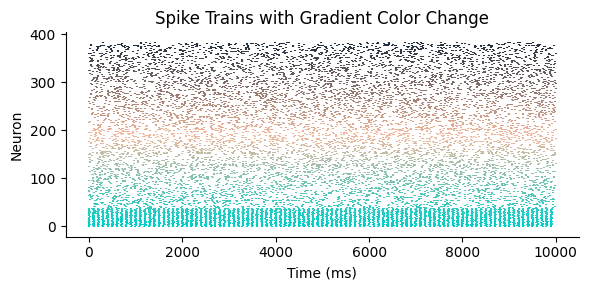

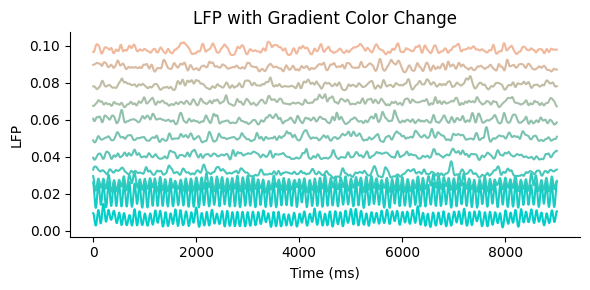

"\n# Plot LFP with Gradient Colors\nplt.figure(figsize=(15, 8))\nnum_samples = 10\nsample_indices = np.linspace(0, num_cols - 1, num_samples).astype(int)\n\nfor row in range(num_rows):\n    for idx in sample_indices:\n        color = colors[idx]\n        plt.plot(lfp[row, idx, :] + idx * 0.0005 + row * 0.002, color=color, label=f'Row {row + 1} Electrode {idx}')\nplt.title('LFP with Gradient Color Change')\nplt.xlabel('Time (ms)')\nplt.ylabel('LFP')\nplt.tight_layout()\nplt.show()\n"

In [62]:
# Main script
spike_trains = generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction)
lfp = generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols)



# Define the specific color palette from the image
#palette = ['#335f8d', '#6d94c7', '#a9cfe8', '#d9f7ff', '#f4b89b', '#1e2d3d']
palette = ['#d9f7ff', '#f4b89b', '#1e2d3d']
palette = ['#00CEC8', '#f4b89b', '#1e2d3d']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_blue_gradient', palette)
colors = [cmap(i/num_neurons) for i in range(num_neurons)]



# Plot Spike Trains with Gradient Colors
plt.figure(figsize=(6, 3))
for idx in range(num_neurons):
    color = colors[idx]
    spike_times = np.where(spike_trains[idx, :] > 0)[0]
    plt.eventplot(spike_times, lineoffsets=idx, linelengths=2.1, colors=color)
plt.title('Spike Trains with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.tight_layout()

# Remove the box using plt.gca()
current_ax = plt.gca()
current_ax.spines['top'].set_visible(False)
current_ax.spines['right'].set_visible(False)
current_ax.spines['left'].set_visible(True)
current_ax.spines['bottom'].set_visible(True)

plt.show()


# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * num_timepoints)
cut_end = int((1 - cut_percent) * num_timepoints)
lfp = lfp[:, :, cut_start:cut_end]


# Plot LFP with Gradient Colors
plt.figure(figsize=(6, 3))
for idx in range(0, num_cols, num_cols//10):
    color = colors[idx]
    plt.plot(lfp[0, idx, :] + idx * 0.0005, color=color)
plt.title('LFP with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.tight_layout()


# Remove the box using plt.gca()
current_ax = plt.gca()
current_ax.spines['top'].set_visible(False)
current_ax.spines['right'].set_visible(False)
current_ax.spines['left'].set_visible(True)
current_ax.spines['bottom'].set_visible(True)

plt.show()


'''
# Plot LFP with Gradient Colors
plt.figure(figsize=(15, 8))
num_samples = 10
sample_indices = np.linspace(0, num_cols - 1, num_samples).astype(int)

for row in range(num_rows):
    for idx in sample_indices:
        color = colors[idx]
        plt.plot(lfp[row, idx, :] + idx * 0.0005 + row * 0.002, color=color, label=f'Row {row + 1} Electrode {idx}')
plt.title('LFP with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.tight_layout()
plt.show()
'''



/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_52297/2515687909.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 100])


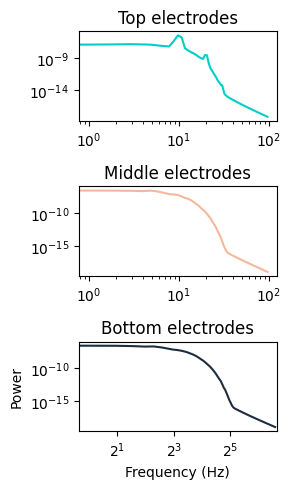

In [63]:
# Divide LFP into top, middle, and bottom segments
lfp_top = lfp[:, :num_cols//2, :]
lfp_middle = lfp[:, int(num_cols//3):int(2*num_cols//3), :]
lfp_bottom = lfp[:, num_cols//2:, :]

# Compute power spectra for each segment
fs = 1000 / resolution
f_top, Pxx_top = compute_average_power_spectrum(lfp_top.reshape(-1, lfp_top.shape[2]), fs)
f_middle, Pxx_middle = compute_average_power_spectrum(lfp_middle.reshape(-1, lfp_middle.shape[2]), fs)
f_bottom, Pxx_bottom = compute_average_power_spectrum(lfp_bottom.reshape(-1, lfp_bottom.shape[2]), fs)

# Plot power spectrum for top, middle, and bottom segments
plt.figure(figsize=(3, 5))
#plt.semilogy(f_top[0:100], Pxx_top[0:100], label='Top', color=palette[0])
#plt.semilogy(f_middle[0:100], Pxx_middle[0:100], label='Middle', color=palette[1])
#plt.semilogy(f_bottom[0:100], Pxx_bottom[0:100], label='Bottom', color=palette[2])
plt.subplot(3,1,1)
plt.loglog(f_top[0:100], Pxx_top[0:100], label='Top', color=palette[0])
plt.title('Top electrodes')
plt.subplot(3,1,2)
plt.loglog(f_middle[0:100], Pxx_middle[0:100], label='Middle', color=palette[1])
plt.title('Middle electrodes')
plt.subplot(3,1,3)

plt.loglog(f_bottom[0:100], Pxx_bottom[0:100], label='Bottom', color=palette[2])
plt.title('Bottom electrodes')

plt.xscale('log', base=2)
plt.yscale('log', base=10)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.xlim([0, 100])
plt.tight_layout()
plt.show()